In [2]:
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz, get_body, ICRS
import astropy.constants as c
from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
import astropy.units as u
from astropy.visualization.wcsaxes.frame import EllipticalFrame
from astropy.visualization.wcsaxes import WCSAxes

from astroquery.hips2fits import hips2fits
hips2fits.timeout = 300 # Necessary to prevent timeouts for downloading large files

from matplotlib import patheffects
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

import os


from regions import Regions, PolygonSkyRegion


%matplotlib widget

hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
global hatch_idx
hatch_idx = 0

In [3]:
def wrap360(ang):
    return ((ang + 360.) % 360.) #what does this do?

In [4]:
EL_MIN = 20
EL_MAX = 52
DAZ_MIN = 90
DAZ_MAX = 225
az_limleft = lambda x: wrap360(x - 270)
az_limright = lambda x: wrap360(x - 135)


mcmurdo = EarthLocation(lat='-77.8419', lon='166.6863', height=37000.)
# mcmurdo = EarthLocation(lat='-77.8419', lon='346.6863', height=37000.) # halfway around continent
launch_date = Time('2026-12-25 00:00:00', scale='utc', location=mcmurdo)

step_hr = .1
oneday = np.arange(0, 24 + step_hr, step_hr) * u.hr
oneweek = np.arange(0, 24 * 7 + step_hr, step_hr) * u.hr
threeweeks = np.arange(24 * 7 * 3 + step_hr, step_hr) * u.hr
times = launch_date + oneday
t = (times - times[0]).to(u.hr) 
sun_body = get_body('sun', times, location=mcmurdo)
sun = SkyCoord(ra=sun_body.ra, dec=sun_body.dec, obstime=times, location=mcmurdo)
sun_altaz = sun.transform_to('altaz')

gal_center = SkyCoord(ra='17h45m40.04s', dec='-29d00m28.s', obstime=times[0], location=mcmurdo)

goods_s = SkyCoord(ra='3h32m36.51s', dec='-27d47m33.74s', obstime=times, location=mcmurdo)
goods_s_altaz = goods_s.transform_to('altaz')

edfs = SkyCoord(ra='04h04m57.84s', dec='-48d25m22.8s', obstime=times[0], location=mcmurdo)

edff = SkyCoord(ra='03h31m43.6s', dec='-28d05m18.6s', obstime=times[0], location=mcmurdo)

In [5]:
def plot_from_catalog_helper_t_vs_el(ax, name, skycoord_override=None):
    global hatch_idx
    if not skycoord_override:
        foo = SkyCoord.from_name(name)
        coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    else:
        coord = skycoord_override
    foo_altaz = coord.transform_to(AltAz)
    l, = ax.plot(t, foo_altaz.alt.deg, marker='.', label=name) # comma means this is a tuple unpacking

    in_bounds = np.where((foo_altaz.alt.deg >= EL_MIN) & (foo_altaz.alt.deg <= EL_MAX))[0]
    for i0, i1 in zip(range(len(t))[:-1], range(len(t))[1:]):
        if (i0 in in_bounds) and (i1 in in_bounds):
            ax.axvspan(t[i0].value, t[i1].value, alpha=0.2, color=l.get_color(), hatch=hatches[hatch_idx])
    hatch_idx += 1
    return coord, foo_altaz


def plot_from_catalog_helper_t_vs_delta_sun(ax, name, skycoord_override=None):
    global hatch_idx
    if not skycoord_override:
        foo = SkyCoord.from_name(name)
        coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    else:
        coord = skycoord_override
    foo_altaz = coord.transform_to(AltAz)

    sun_body = get_body('sun', times, location=mcmurdo)
    sun = SkyCoord(ra=sun_body.ra, dec=sun_body.dec, obstime=times, location=mcmurdo)
    sun_altaz = sun.transform_to('altaz')

    delta_az = wrap360(foo_altaz.az.deg - sun_altaz.az.deg)
    l, = ax.plot(t, delta_az, marker='.', label=f'{name} Az - Sun Az')

    in_bounds = np.where((delta_az >= DAZ_MIN) & (delta_az <= DAZ_MAX))[0]
    for i0, i1 in zip(range(len(t))[:-1], range(len(t))[1:]):
        if (i0 in in_bounds) and (i1 in in_bounds):
            ax.axvspan(t[i0].value, t[i1].value, alpha=0.2, color=l.get_color(), hatch=hatches[hatch_idx])
    hatch_idx += 1
    return coord, foo_altaz, sun_altaz

<>:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14532\754030919.py:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax[3].set_ylabel('$\Delta$Az (deg +from North)')


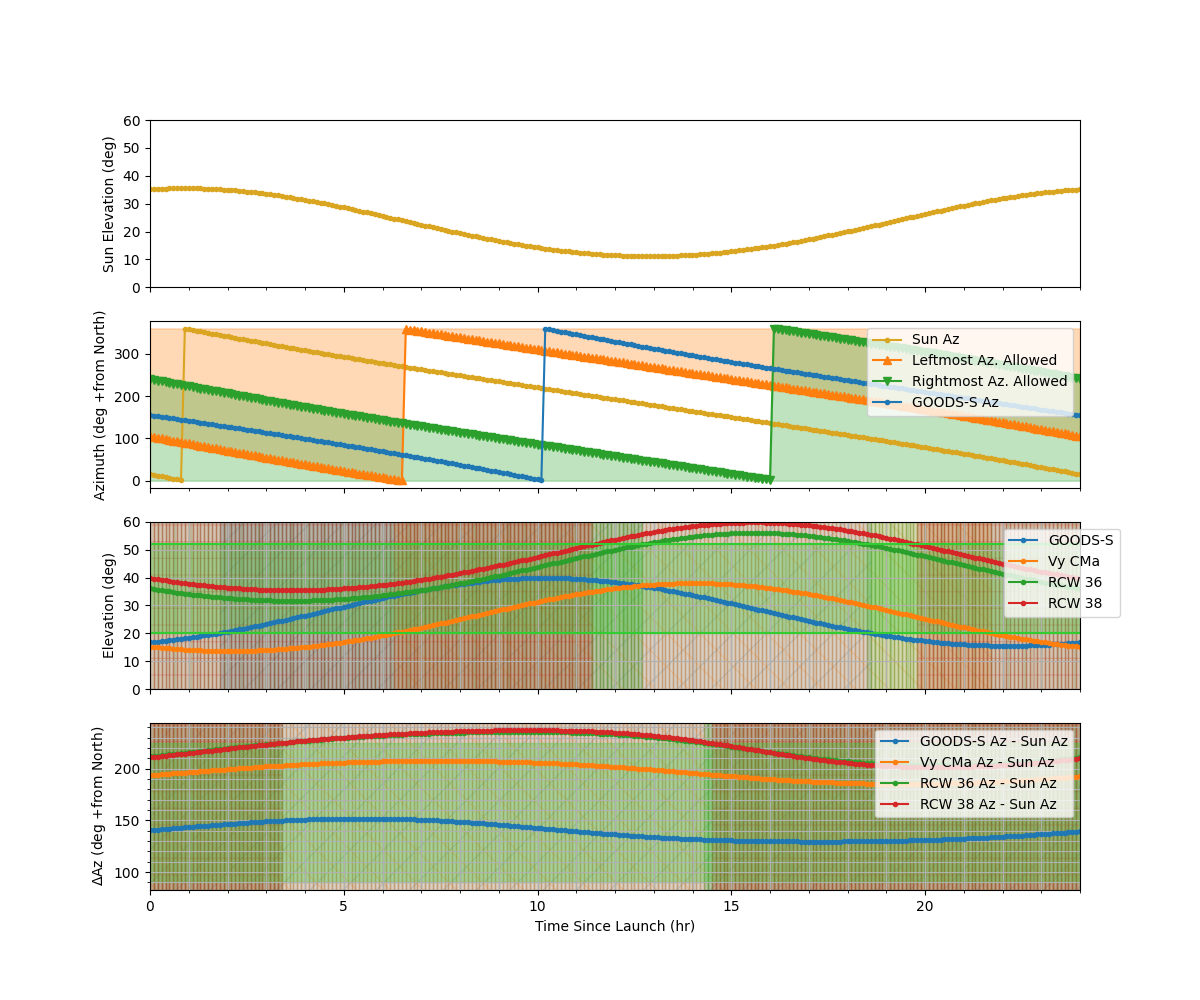

In [6]:
fig, ax = plt.subplots(figsize=(12,10), nrows=4, sharex=True)

ax[0].plot(t, sun_altaz.alt.deg, marker='.', color='goldenrod')
ax[0].set_ylim(0, 60)
ax[0].set_ylabel('Sun Elevation (deg)')

ax[1].plot(t, sun_altaz.az.deg, marker='.', color='goldenrod', label='Sun Az')
ax[1].plot(t, az_limleft(sun_altaz.az.deg), marker='^', color='C1', label='Leftmost Az. Allowed')
ax[1].fill_between(t.value, az_limleft(sun_altaz.az.deg), color='C1', y2=360, alpha=0.3)
ax[1].plot(t, az_limright(sun_altaz.az.deg), marker='v', color='C2', label='Rightmost Az. Allowed')
ax[1].fill_between(t.value, az_limright(sun_altaz.az.deg), color='C2', y2=0, alpha=0.3)
ax[1].plot(t, goods_s_altaz.az.deg, marker='.', label='GOODS-S Az')
ax[1].set_ylabel('Azimuth (deg +from North)')
ax[1].legend(loc='upper right')

hatch_idx = 0
plot_from_catalog_helper_t_vs_el(ax[2], 'GOODS-S', skycoord_override=goods_s)
plot_from_catalog_helper_t_vs_el(ax[2], 'Vy CMa')
# rcw19, _, = plot_from_catalog_helper_t_vs_el(ax[2], 'RCW 19')
# rcw20, _ = plot_from_catalog_helper_t_vs_el(ax[2], 'RCW 20')
rcw36, _ = plot_from_catalog_helper_t_vs_el(ax[2], 'RCW 36')
rcw38, _ = plot_from_catalog_helper_t_vs_el(ax[2], 'RCW 38')
# plot_from_catalog_helper_t_vs_el(ax[2], 'NGC 253')
# plot_from_catalog_helper_t_vs_el(ax[2], '[MHL2007] G259.0453-01.5559 1')
# plot_from_catalog_helper_t_vs_el(ax[2], 'IRAS 08088-3554')
# plot_from_catalog_helper_t_vs_el(ax[2], 'CG 30')
# plot_from_catalog_helper_t_vs_el(ax[2], 'IRAS 08448-4343')

ax[2].axhline(EL_MIN, color='limegreen')
ax[2].fill_between(t.value, EL_MIN, y2=EL_MAX, color='limegreen', alpha=0.3)
ax[2].axhline(EL_MAX, color='limegreen')
ax[2].set_ylim(0, 60)
ax[2].set_ylabel('Elevation (deg)')
ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper right')
ax[2].grid(which='both')
ax[2].set_xlim(t[0].value, t[-1].value)

hatch_idx = 0
plot_from_catalog_helper_t_vs_delta_sun(ax[3], 'GOODS-S', skycoord_override=goods_s)
plot_from_catalog_helper_t_vs_delta_sun(ax[3], 'Vy CMa')
# plot_from_catalog_helper_t_vs_delta_sun(ax[3], 'RCW 19')
plot_from_catalog_helper_t_vs_delta_sun(ax[3], 'RCW 36')
plot_from_catalog_helper_t_vs_delta_sun(ax[3], 'RCW 38')

ax[3].fill_between(t.value, DAZ_MIN, y2=DAZ_MAX, color='limegreen', alpha=0.3)
ax[3].set_ylabel('$\Delta$Az (deg +from North)')
ax[3].legend(loc='upper right')
ax[3].grid(which='both')
# ax[3].set_ylim(0, 360)
ax[3].set_xlabel('Time Since Launch (hr)')

plt.minorticks_on()

In [7]:
def altaz_to_radec_helper(alt, az):
    my_radec = SkyCoord(
        AltAz(
            alt=alt,
            az=az,
            obstime=times,
            location=mcmurdo
        )
    ).transform_to(ICRS)
    return my_radec

In [8]:
def plot_from_catalog_helper(ax, name):
    foo = SkyCoord.from_name(name)
    coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    ax.scatter(coord.ra, coord.dec, edgecolor='k', transform=ax.get_transform('icrs'), label=name)
    return foo

Plot a polygon on sky connecting the RA/Dec coordinates dictated by the el axis limits and the sun. One polygon per time coordinate

In [9]:
def allsky_query(hips, reload=False):
    fname = hips.replace('/', '_') + '.fits'
    if os.path.exists(fname) and reload:
        result = hips2fits.query(
            hips=hips,
            ra=0 * u.deg,
            dec=0 * u.deg,
            width=5000,
            height=2500,
            fov=360 * u.deg,
            projection='MOL',
            get_query_payload=False,
            format='fits',
        )
        result.writeto(fname, overwrite=True)

    hdu = fits.open(fname)
    h = hdu[0].header
    wcs = WCS(h, naxis=2) # reduce WCS dimensionality for polygon overplot
    d = hdu[0].data
    return wcs, h, d

In [10]:
# https://alasky.cds.unistra.fr/hips-image-services/hips2fits
wcs, h, d0 = allsky_query('CDS/P/IRIS/color', reload=False)
d0 = d0[2,:,:]

FileNotFoundError: [Errno 2] No such file or directory: 'CDS_P_IRIS_color.fits'

In [ ]:
wcs, h, d1 = allsky_query('ESAVO/P/HERSCHEL/SPIRE-350', reload=False)

FileNotFoundError: [Errno 2] No such file or directory: 'ESAVO_P_HERSCHEL_SPIRE-350.fits'

In [ ]:
ds = [d1, d0]

Text(0.5, 0.98, 'Observing Time: 1.0 days')

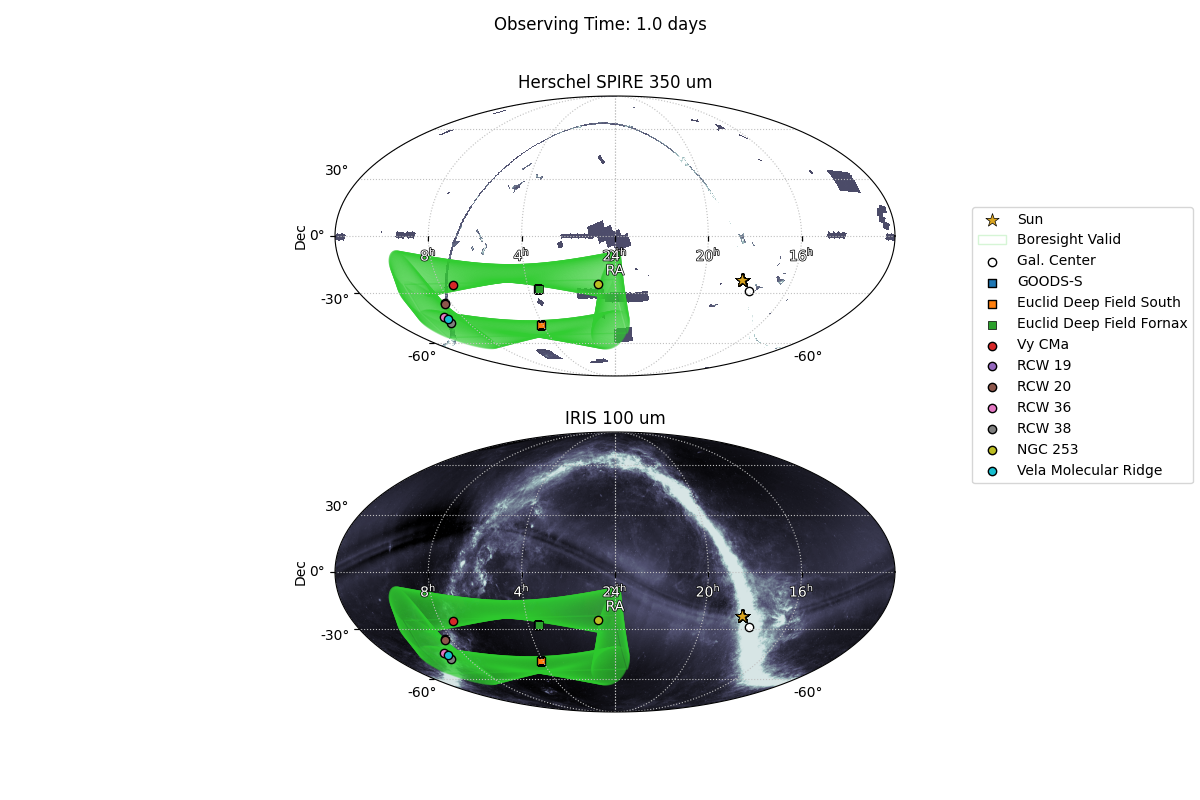

In [ ]:
fig, axs = plt.subplots(figsize=(12,8), nrows=2, subplot_kw=dict(projection=wcs, frame_class=EllipticalFrame), sharex=True, sharey=True)
ax0, ax1 = axs

for j, ax in enumerate(axs):
    d = ds[j]

    lon = ax.coords[0]
    lat = ax.coords[1]
    lat.set_axislabel_position("c")

    path_effects=[patheffects.withStroke(linewidth=1, foreground='black')]
    lon.set_ticklabel(color='white', path_effects=path_effects)
    ax.grid(linestyle=':', color='silver')

    ax.imshow(d, vmin=np.nanmin(d), vmax=np.nanmean(d) + 2 * np.nanstd(d), cmap='bone')

    p = ax.scatter(sun.ra, sun.dec, s=100, marker='*', facecolor='goldenrod', edgecolor='k', linewidth=.5, transform=ax.get_transform('icrs'), label='Sun')

    limleftup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limrightup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limright(sun_altaz.az.deg) * u.deg)

    # coordinates of corners on plot
    # p = ax.scatter(limleftup_radec.ra, limleftup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftmid_radec.ra, limleftmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftdown_radec.ra, limleftdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightup_radec.ra, limrightup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightmid_radec.ra, limrightmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightdown_radec.ra, limrightdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))

    rs = []
    for i in range(len(limleftup_radec)):
        verts = SkyCoord([
                limleftup_radec.ra[i],
                limleftmid_radec.ra[i],
                limleftdown_radec.ra[i],
                limrightdown_radec.ra[i],
                limrightmid_radec.ra[i],
                limrightup_radec.ra[i],
            ],
            [
                limleftup_radec.dec[i],
                limleftmid_radec.dec[i],
                limleftdown_radec.dec[i],
                limrightdown_radec.dec[i],
                limrightmid_radec.dec[i],
                limrightup_radec.dec[i],
            ],
            unit='deg',
            frame=ICRS
        )
        reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='limegreen', facecolor=None))
        rs.append(reg)
    regions = Regions(rs)
    regions.write('myregions.reg', format='ds9', overwrite=True)

    px_regions = [r.to_pixel(wcs) for r in rs]
    for i, p in enumerate(px_regions):
        if i == 0:
            p.plot(ax=ax, edgecolor='limegreen', facecolor='none', alpha=max(1/len(times), 0.2), label='Boresight Valid')
        # p.plot(ax=ax, edgecolor='k', alpha=max(1/len(times), 0.01))
        p.plot(ax=ax, facecolor='none', edgecolor='limegreen', alpha=0.2)

    # some additional points of interest
    ax.scatter(gal_center.ra, gal_center.dec, facecolor='w', edgecolor='k', transform=ax.get_transform('icrs'), label='Gal. Center')
    ax.scatter(goods_s.ra, goods_s.dec, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='GOODS-S')
    ax.scatter(edfs.ra, edfs.dec, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field South')
    ax.scatter(edff.ra, edff.dec, marker='s', linewidth=0.5, edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field Fornax')

    plot_from_catalog_helper(ax, 'Vy CMa')
    rcw19 = plot_from_catalog_helper(ax, 'RCW 19')
    rcw20 = plot_from_catalog_helper(ax, 'RCW 20')
    rcw36 = plot_from_catalog_helper(ax, 'RCW 36')
    rcw38 = plot_from_catalog_helper(ax, 'RCW 38')
    # plot_from_catalog_helper(ax, 'RCW 42')
    # plot_from_catalog_helper(ax, 'RCW 49')
    # plot_from_catalog_helper(ax, 'Carina Nebula')
    plot_from_catalog_helper(ax, 'NGC 253')
    # plot_from_catalog_helper(ax, 'NGC 3576')
    # plot_from_catalog_helper(ax, 'NGC 3603')
    plot_from_catalog_helper(ax, 'Vela Molecular Ridge')
    # plot_from_catalog_helper(ax, 'Beta Gruis')
    # plot_from_catalog_helper(ax, '[MHL2007] G259.0453-01.5559 1') # Young Stellar Object Candidate
    # plot_from_catalog_helper(ax, 'NGC 2579')
    # plot_from_catalog_helper(ax, 'IRAS 08088-3554')
    # plot_from_catalog_helper(ax, 'CG 30')
    # plot_from_catalog_helper(ax, 'IRAS 08448-4343')

    # for hh in [120, 132, 133, 171, 188, 217, 219, 246]: # [46, 47, 72, 73, 74, 75,]
    #     plot_from_catalog_helper(ax, 'HH' + str(hh))

    ax.set_xlabel('RA', color='w', path_effects=path_effects)
    ax.set_ylabel('Dec')
    if j == 0:
        ax.legend(loc='upper right', ncol=1, bbox_transform=fig.transFigure, bbox_to_anchor=(1, 0.75))
    # fig.tight_layout()

ax0.set_title('Herschel SPIRE 350 um')
ax1.set_title('IRIS 100 um')
fig.suptitle(f'Observing Time: {(t[-1] - t[0]).to(u.day).value:.1f} days')

# fig.tight_layout()

astroplan constraints

In [ ]:
from astroplan import Observer, FixedTarget, Constraint, AltitudeConstraint, SunSeparationConstraint
from astroplan import is_observable, is_always_observable, observability_table
from astroplan.plots import plot_sky, plot_parallactic, plot_altitude, plot_finder_image
from astroplan.target import get_skycoord

In [ ]:
ldb = (-77.861 * u.deg, 167.061 * u.deg)

# ground track:
# Salter Test Flight Universal completed ~1 circuit in 11 days, 6 hr, 57 min. Average the longitudinal velocity.
# Really, ballons have a spatial velocity, so this constant lat assumption is an oversimplification.
dlon_dt = (360 * u.deg / (11 * u.day + 6 * u.hr + 57 * u.min)).to(u.deg / u.hr)
lon = ldb[1] + dlon_dt * t
lat = np.ones_like(lon.value) * ldb[0]

In [ ]:
class SunRelativeAzConstraint(Constraint):
    '''
    Constrain an asymmetrical sun-relative azimuth pointing of the boresight to
    target.
    These angles are the angles that the boresight must point away from the sun
    in order to maintain the instrument and electronics in the shade of the
    sunshade. As always, azimuth is measured +clockwise from the reference
    point, in this case the sun azimuth. The range is [0, 360] deg.
    '''
    def __init__(self, min=None, max=None):
        '''
        min : `~astropy.units.Quantity` or `None` (optional)
            Minimum acceptable azimuth angle between sun and boresight. `None`
            indicates no limit.
        max : `~astropy.units.Quantity` or `None` (optional)
            Maximum acceptable azimuth angle between sun and boresight. `None`
            indicates no limit.
        '''
        self.min = min if min is not None else 0*u.deg
        self.max = max if max is not None else 360*u.deg


    def compute_constraint(self, times, observer, targets):
        targets = get_skycoord(targets)
        sun_body = get_body('sun', times, location=observer.location)
        sun = SkyCoord(ra=sun_body.ra, dec=sun_body.dec, obstime=times,
                       location=observer.location)
        sun_altaz = sun.transform_to('altaz')

        # Calculate separation between boresight and sun
        # Targets are automatically converted to SkyCoord objects
        # by __call__ before compute_constraint is called.
        n_targets = len(targets)
        n_times = len(times)

        delta_az = np.empty((n_targets, n_times)) * u.deg
        for i, target in enumerate(targets):
            target_with_loc = SkyCoord(ra=target.ra, dec=target.dec, obstime=times, location=observer.location)
            target_altaz = target_with_loc.transform_to('altaz')
            delta_az[i,:] = wrap360(target_altaz.az.deg - sun_altaz.az.deg) * u.deg # time axis

        if self.min is None and self.max is not None:
            mask = self.max >= delta_az
        elif self.max is None and self.min is not None:
            mask = self.min <= delta_az
        elif self.min is not None and self.max is not None:
            mask = ((self.min <= delta_az) &
                    (delta_az <= self.max))
        else:
            raise ValueError("No max and/or min specified in "
                             "SunRelativeAzConstraint.")
        return mask

In [ ]:
tim = Observer(longitude=lon, latitude=lat, elevation=37000 * u.km, name="TIM")
targets = [
    FixedTarget(coord=rcw19, name='RCW 19'),
    FixedTarget(coord=rcw36, name='RCW 36'),
    FixedTarget(coord=rcw38, name='RCW 38')
]
constraints = [
    AltitudeConstraint(20 * u.deg, 52 * u.deg),
    SunRelativeAzConstraint(min=90 * u.deg, max=225 * u.deg)
]

In [ ]:
observability_table(constraints, tim, targets, times)

In [ ]:
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'))

plot_sky(targets[0], tim, times, ax=ax)
plot_sky(targets[1], tim, times, ax=ax)
plot_sky(targets[2], tim, times, ax=ax)

ax.legend()

# Visibility From December 2026 to Feburary 2027

In [11]:

start_date = Time('2026-12-01 00:00:00', scale='utc', location=mcmurdo)
end_date = Time('2027-03-01 00:00:00', scale='utc', location=mcmurdo)

# Create daily sampling
step_day = 1  
num_days = (end_date - start_date).to(u.day).value
times_3month = start_date + np.arange(0, num_days, step_day) * u.day
t_3month = (times_3month - times_3month[0]).to(u.day)

print(f"Time range: {times_3month[0].iso} to {times_3month[-1].iso}")
print(f"Number of days: {len(times_3month)}")

# Compute sun positions
sun_body_3month = get_body('sun', times_3month, location=mcmurdo)
sun_3month = SkyCoord(ra=sun_body_3month.ra, dec=sun_body_3month.dec, obstime=times_3month, location=mcmurdo)
sun_altaz_3month = sun_3month.transform_to('altaz')

# Compute target positions
goods_s_3month = SkyCoord(ra='3h32m36.51s', dec='-27d47m33.74s', obstime=times_3month, location=mcmurdo)
goods_s_altaz_3month = goods_s_3month.transform_to('altaz')

Time range: 2026-12-01 00:00:00.000 to 2027-02-28 00:00:00.000
Number of days: 90


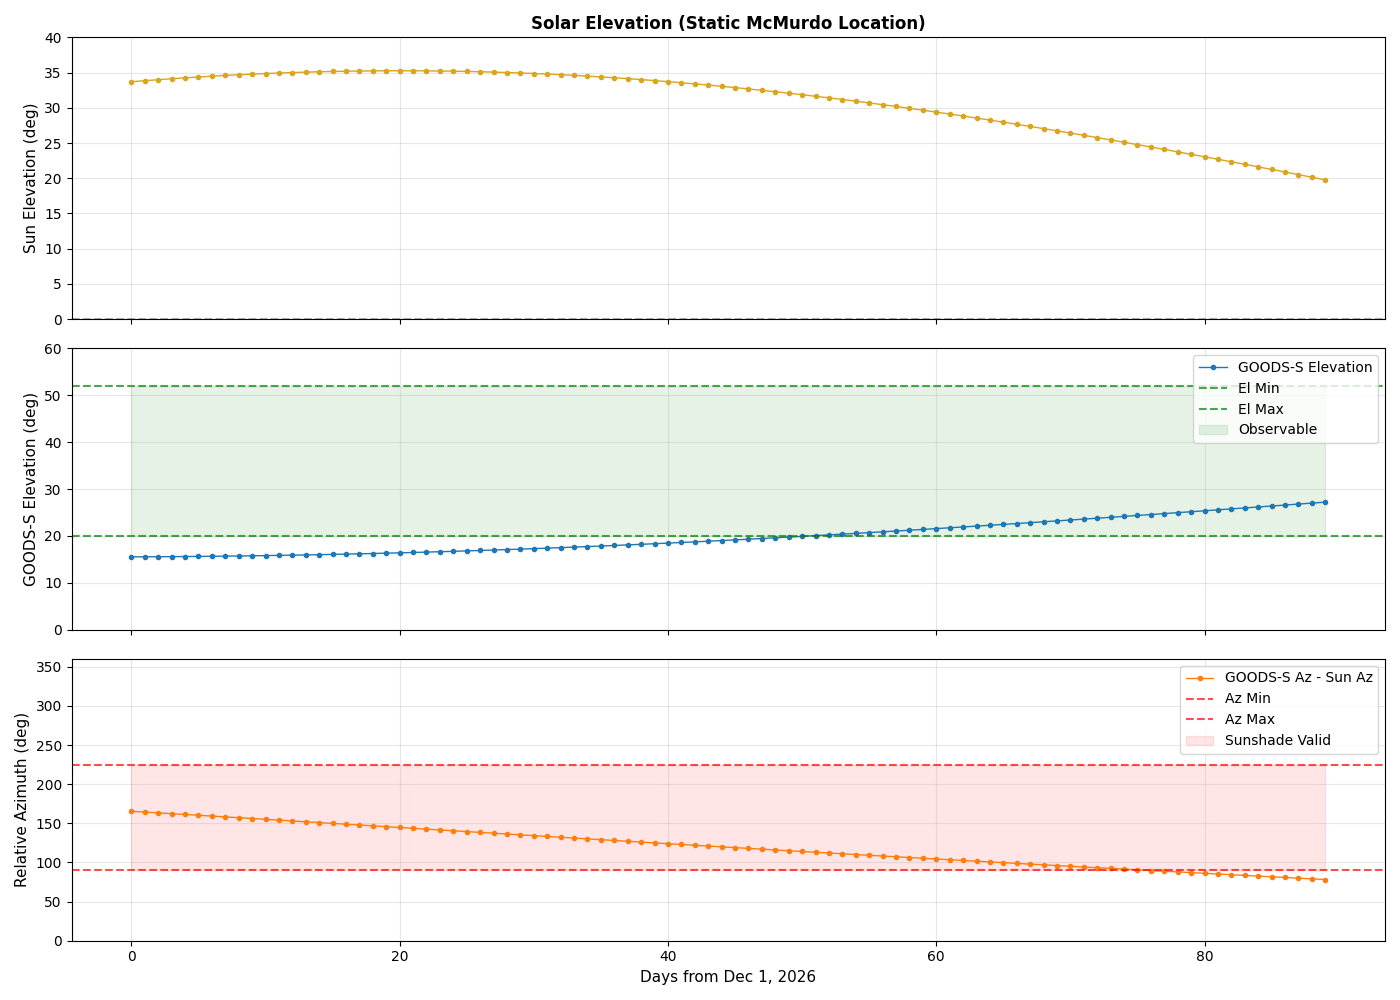

In [12]:
# static McMurdo location - no balloon orbit
fig, ax = plt.subplots(figsize=(14, 10), nrows=3, sharex=True)

# Plot 1: Sun elevation
ax[0].plot(t_3month.value, sun_altaz_3month.alt.deg, marker='o', markersize=3, color='goldenrod', linewidth=1)
ax[0].axhline(0, color='k', linestyle='--', alpha=0.3)
ax[0].set_ylabel('Sun Elevation (deg)', fontsize=11)
ax[0].set_ylim(0, 40)
ax[0].grid(True, alpha=0.3)
ax[0].set_title('Solar Elevation (Static McMurdo Location)', fontsize=12, fontweight='bold')

# Plot 2: GOODS-S elevation vs constraint
ax[1].plot(t_3month.value, goods_s_altaz_3month.alt.deg, marker='o', markersize=3, color='C0', label='GOODS-S Elevation', linewidth=1)
ax[1].axhline(EL_MIN, color='g', linestyle='--', label='El Min', alpha=0.7)
ax[1].axhline(EL_MAX, color='g', linestyle='--', label='El Max', alpha=0.7)
ax[1].fill_between(t_3month.value, EL_MIN, EL_MAX, color='green', alpha=0.1, label='Observable')
ax[1].set_ylabel('GOODS-S Elevation (deg)', fontsize=11)
ax[1].set_ylim(0, 60)
ax[1].legend(loc='upper right')
ax[1].grid(True, alpha=0.3)

# Plot 3: Relative azimuth (GOODS-S relative to Sun)
delta_az_3month = goods_s_altaz_3month.az.deg - sun_altaz_3month.az.deg
ax[2].plot(t_3month.value, delta_az_3month, marker='o', markersize=3, color='C1', label='GOODS-S Az - Sun Az', linewidth=1)
ax[2].axhline(DAZ_MIN, color='r', linestyle='--', label='Az Min', alpha=0.7)
ax[2].axhline(DAZ_MAX, color='r', linestyle='--', label='Az Max', alpha=0.7)
ax[2].fill_between(t_3month.value, DAZ_MIN, DAZ_MAX, color='red', alpha=0.1, label='Sunshade Valid')
ax[2].set_ylabel('Relative Azimuth (deg)', fontsize=11)
ax[2].set_xlabel('Days from Dec 1, 2026', fontsize=11)
ax[2].set_ylim(0, 360)
ax[2].legend(loc='upper right')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

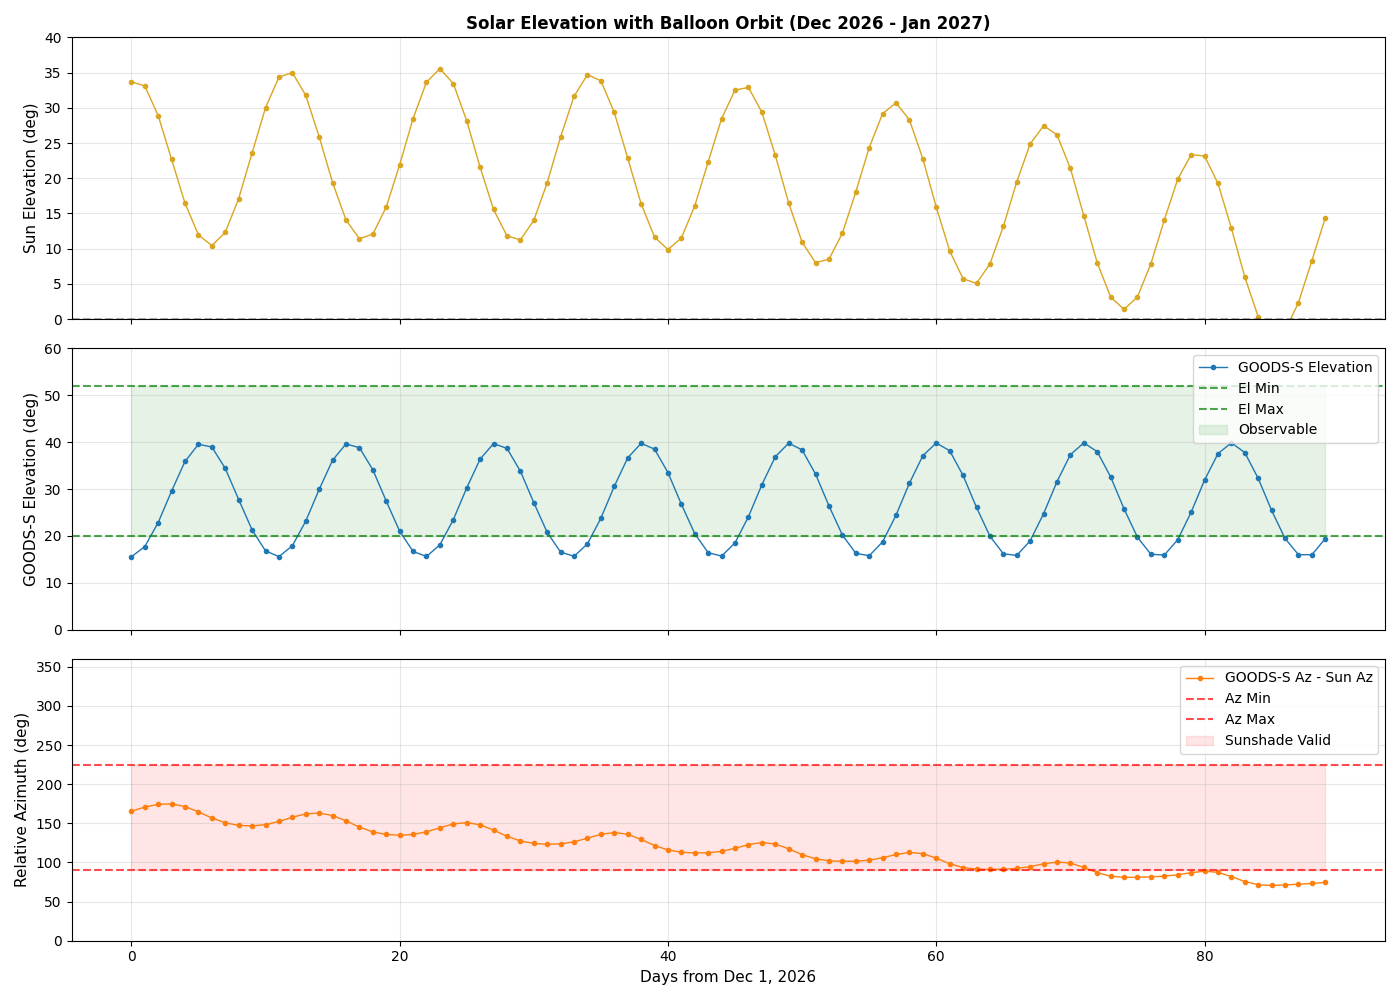

In [14]:
# Create visibility plot 

fig, ax = plt.subplots(figsize=(14, 10), nrows=3, sharex=True)

# Calculate balloon position over time while it is orbiting around Antarctica
ldb = (-77.861 * u.deg, 167.061 * u.deg)
dlon_dt = (360 * u.deg / (11 * u.day + 6 * u.hr + 57 * u.min)).to(u.deg / u.day)
lon_3month = ldb[1] + dlon_dt * t_3month
lat_3month = np.ones_like(lon_3month.value) * ldb[0]
locations_3month = [EarthLocation(lat=lat_3month[i], lon=lon_3month[i], height=37000.) 
                    for i in range(len(t_3month))]

# Recompute sun positions with dynamic locations
sun_altaz_3month_list = []
for i, (time, loc) in enumerate(zip(times_3month, locations_3month)):
    sun_body_i = get_body('sun', time, location=loc)
    sun_i = SkyCoord(ra=sun_body_i.ra, dec=sun_body_i.dec, obstime=time, location=loc)
    sun_altaz_3month_list.append(sun_i.transform_to('altaz'))

sun_altaz_3month_alt = np.array([s.alt.deg for s in sun_altaz_3month_list]) * u.deg
sun_altaz_3month_az = np.array([s.az.deg for s in sun_altaz_3month_list]) * u.deg

# Recompute GOODS-S positions
goods_s_altaz_3month_list = []
for i, (time, loc) in enumerate(zip(times_3month, locations_3month)):
    goods_s_i = SkyCoord(ra='3h32m36.51s', dec='-27d47m33.74s', obstime=time, location=loc)
    goods_s_altaz_3month_list.append(goods_s_i.transform_to('altaz'))

goods_s_altaz_3month_alt = np.array([g.alt.deg for g in goods_s_altaz_3month_list]) * u.deg
goods_s_altaz_3month_az = np.array([g.az.deg for g in goods_s_altaz_3month_list]) * u.deg

# Plot 1: Sun elevation
ax[0].plot(t_3month.value, sun_altaz_3month_alt.value, marker='o', markersize=3, color='goldenrod', linewidth=1)
ax[0].axhline(0, color='k', linestyle='--', alpha=0.3)
ax[0].set_ylabel('Sun Elevation (deg)', fontsize=11)
ax[0].set_ylim(0, 40)
ax[0].grid(True, alpha=0.3)
ax[0].set_title('Solar Elevation with Balloon Orbit (Dec 2026 - Jan 2027)', fontsize=12, fontweight='bold')

# Plot 2: GOODS-S elevation vs constraint
ax[1].plot(t_3month.value, goods_s_altaz_3month_alt.value, marker='o', markersize=3, color='C0', label='GOODS-S Elevation', linewidth=1)
ax[1].axhline(EL_MIN, color='g', linestyle='--', label='El Min', alpha=0.7)
ax[1].axhline(EL_MAX, color='g', linestyle='--', label='El Max', alpha=0.7)
ax[1].fill_between(t_3month.value, EL_MIN, EL_MAX, color='green', alpha=0.1, label='Observable')
ax[1].set_ylabel('GOODS-S Elevation (deg)', fontsize=11)
ax[1].set_ylim(0, 60)
ax[1].legend(loc='upper right')
ax[1].grid(True, alpha=0.3)

# Plot 3: Relative azimuth (GOODS-S relative to Sun)
delta_az_3month = wrap360(goods_s_altaz_3month_az.value - sun_altaz_3month_az.value)
ax[2].plot(t_3month.value, delta_az_3month, marker='o', markersize=3, color='C1', label='GOODS-S Az - Sun Az', linewidth=1)
ax[2].axhline(DAZ_MIN, color='r', linestyle='--', label='Az Min', alpha=0.7)
ax[2].axhline(DAZ_MAX, color='r', linestyle='--', label='Az Max', alpha=0.7)
ax[2].fill_between(t_3month.value, DAZ_MIN, DAZ_MAX, color='red', alpha=0.1, label='Sunshade Valid')
ax[2].set_ylabel('Relative Azimuth (deg)', fontsize=11)
ax[2].set_xlabel('Days from Dec 1, 2026', fontsize=11)
ax[2].set_ylim(0, 360)
ax[2].legend(loc='upper right')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'reuter_2020_data/smg_dndz_tables.fits'